In [ ]:
"""
The training data volume was too large to upload. Please check our execution history. For specific requests for training data, please contact 573208985@qq.com.
"""

In [ ]:
import  sklearn
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings
from sklearn import preprocessing
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import copy
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time
import lightgbm as lgb
from sklearn.model_selection import KFold
import torch
import torch.optim as optim
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
import numpy as np
from xgboost import DMatrix, train
from sklearn.datasets import make_regression
import torch.optim as optim
np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
import pickle
import glob
import numpy as np
from scipy.stats import *
import xgboost as xgb
import torch.nn.functional as F
import numpy as np
from scipy.stats import mode
import copy
from torch.utils.data import Dataset, DataLoader
import torch
import os

matplotlib.rcParams['font.sans-serif'] = ['SimHei']  
matplotlib.rcParams['axes.unicode_minus'] = False  

def set_seed(seed):
    import random
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

cols_names= [
        "Pid","IDW", "FABDEM", "GEDTM30", "FathomDEM", "HRDEM", "Lon", "Lat","LandCover", "LandForm",
        "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",
        "BuildingHeight90", "Pop", "NightLight",
        "Aspect", "Hillshade", "Curvature", "ProfileCur", "PlanCur", 
        "DEM", "MeanDEM", "MedianDEM", "MaxDEM", "MinDEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
        "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HeightError","FCLoss","FCGain","NIR" 
    ]

usingFeatures = ['DEM', 'ForestCoverage','ForestHeight', 'ForestHeight10', 'ForestHeight30','BuildingHeight90' , 'HeightError', 'FCLoss',  'FCGain', 'ProfileCur', 'Aspect', 'NIR', 'Hillshade']



"""---------global variables------"""
train_data,val_data,test_data,train_labels,val_labels,test_labels=None,None,None,None,None,None
test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30=None,None,None,None,None,None

train_loader,val_loader,test_loader=None,None,None
featureNum,landformArray=None,None



d:\Anaconda3\envs\ddl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Validation

In [ ]:

sample_indices=[]

"""
For prediction .....
"""
def predictModel(model=None,loadModel=None,test_loader=None): 

    checkpoint = torch.load(loadModel)
    model.load_state_dict(checkpoint['model_state_dict'])    

    model.eval() 
    
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X=batch_X.cuda()
            batch_y=batch_y.cuda()

            preds = model(batch_X)
            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())


    y_pred = torch.cat(all_preds, dim=0)
    y_true = torch.cat(all_labels, dim=0)

    RMSE_NSCNN = (nn.functional.mse_loss(y_pred, y_true, reduction='mean').item())**0.5
    
    all_labels = torch.cat([torch.tensor(labels) for labels in all_labels], dim=0)
    rmse_zero = (F.mse_loss(all_labels, torch.zeros_like(all_labels), reduction='mean').item())**0.5
    print(f"RMSE: {rmse_zero:0.2f}")
  
    return RMSE_NSCNN


 

# Training

In [ ]:


def trainNSCNN(model,epochs=5000,earlyStop=10,save_model_path=None,IsContinueTrain=False,preModelPath=None,train_loader=None,val_loader=None):

    criterion = nn.MSELoss().cuda()

    best_val_loss = float('inf')
    best_test_imp = -1
    best_epoch = 0
    no_improve_count, no_improve_lr_count = 0, 0
    cur_epoch=0
    lr=0.001
    
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Record loss
    train_losses = []
    val_losses = []

    # Early stopping configuration
    train_losses, val_losses = [], []
    

    #-------------------------  loop-----------------------
    for epoch in range(cur_epoch,epochs):
        model.train()
        epoch_train_loss = 0
        
        #---------------------------------- Training------------------------------
        for batch_x, batch_y in train_loader:
            batch_x=batch_x.cuda()
            batch_y=batch_y.cuda()

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_x.size(0)  # meanloss * sampple numbers
            # print(epoch_train_loss)
        
        # Average train loss
        epoch_train_loss = epoch_train_loss/len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # ----------------------------Validation-------------------------
        val_loss_sum=0
        with torch.no_grad():
            for val_x, val_y in val_loader:
                val_x=val_x.cuda()
                val_y=val_y.cuda()

                val_outputs = model(val_x)
                val_loss = criterion(val_outputs, val_y)
                val_loss_sum += val_loss.item() * val_x.size(0)

            val_loss_avg = val_loss_sum / len(val_loader.dataset) 
        
        val_losses.append(val_loss_avg)

        
  
        if val_loss_avg < best_val_loss:
            best_epoch, best_val_loss = epoch, val_loss_avg
            torch.save({'model_state_dict': model.state_dict(),'best_val_loss': best_val_loss,'best_model_epoch':epoch}, save_model_path)
            no_improve_count, no_improve_lr_count = 0, 0    
        else: 

            no_improve_count += 1
            no_improve_lr_count += 1

      
        if no_improve_lr_count >=10:
            lr=optimizer.param_groups[0]['lr'] 
            lr=lr*0.5
            optimizer.param_groups[0]['lr'] =max(lr,0.00000001)
            no_improve_lr_count = 0  
        
        if no_improve_count >= earlyStop:
            break





# Models

## Common modules

In [4]:




#--------------- ResidualBlock-----------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # shortcut for channel match
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out


#--------------- UpsampleBlock-----------------
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upscale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.relu(x)
        return x
    



In [ ]:

class Unet_512(nn.Module):
    def __init__(self, in_channels):
        super().__init__()


        self.encoder1 = nn.Sequential(ResidualBlock(in_channels, 64))
        self.pool1 = nn.MaxPool2d(2) 
        self.encoder2 = nn.Sequential(ResidualBlock(64, 128))
        self.pool2 = nn.MaxPool2d(2)  
        self.encoder3 = nn.Sequential(ResidualBlock(128, 256))
        self.pool3 = nn.MaxPool2d(2) 
        self.encoder4 = nn.Sequential(ResidualBlock(256, 512))
        self.pool4 = nn.MaxPool2d(2)  

   
        self.up4 = UpsampleBlock(512, 512)
        self.up3 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up1 = UpsampleBlock(128, 64)

    
        self.decoder4 = ResidualBlock(512 * 2, 512)
        self.decoder3 = ResidualBlock(256 * 2, 256)
        self.decoder2 = ResidualBlock(128 * 2, 128)
        self.decoder1 = ResidualBlock(64 * 2, 64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
  
        enc1 = self.encoder1(x)                   # 64x64
        enc2 = self.encoder2(self.pool1(enc1))    # 32x32
        enc3 = self.encoder3(self.pool2(enc2))    # 16x16
        enc4 = self.encoder4(self.pool3(enc3))    # 8x8

        bottom = self.pool4(enc4)                 # 4x4 

  
        dec4 = self.up4(bottom)                   # 8x8
        dec4 = torch.cat((dec4, enc4), dim=1)     
        dec4 = self.decoder4(dec4)               

        dec3 = self.up3(dec4)                     # 16x16
        dec3 = torch.cat((dec3, enc3), dim=1)     
        dec3 = self.decoder3(dec3)             

        dec2 = self.up2(dec3)                     # 32x32
        dec2 = torch.cat((dec2, enc2), dim=1)   
        dec2 = self.decoder2(dec2)              

        dec1 = self.up1(dec2)                     # 64x64
        dec1 = torch.cat((dec1, enc1), dim=1)   
        dec1 = self.decoder1(dec1)             

        out = self.conv_out(dec1)               
        out = out.squeeze(1)                     
        return out



# Traning data

In [ ]:
import numpy as np
from sklearn.utils import shuffle

usingFeatures = [
    "IDW", "Lon", "Lat","LandCover",  "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Pop", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCur", "PlanCur",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


Base_add_Filtered=["ForestHeight", "ForestHeight10", "ForestHeight30","DEM", "BuildingHeight90",
                   'HEL','ForestCoverage', 'Aspect', 'Hillshade',  'NIR', 'deltMinDEM', 'RGB', 'ProfileCur', 'Pop', 'SAR_VV', 'Curvature', 'NightLight',  'FCLoss', 'deltMeanSlope', 'SOA', 'deltMaxDEM',  'FCGain', 'SOS' ]



baseFeatures=["DEM", "ForestHeight", "ForestHeight10", "ForestHeight30","BuildingHeight90"]

removeClustered=['HEL','ForestCoverage', 'Aspect', 'Hillshade',  'NIR', 'deltMinDEM', 'RGB', 'ProfileCur', 'Pop', 'SAR_VV', 'Curvature', 'NightLight',  'FCLoss', 'deltMeanSlope', 'SOA', 'deltMaxDEM',  'FCGain', 'SOS' ]



def load_tabular_from_npz(paths, sample_ratio=0.05, IsShuffle=True, mean_std_path=None,test_ratio=0.2):

    selected_indices = [usingFeatures.index(feat) for feat in Base_add_Filtered]


    mean_val_all = np.load(mean_std_path)['mean']
    std_val_all = np.load(mean_std_path)['std']

    mean_val = mean_val_all[0, selected_indices, 0, 0] 
    std_val = std_val_all[0, selected_indices, 0, 0]    
    
    X_list = []
    y_list = []
    
    for path in paths:
        loaded = np.load(path)
        data = loaded['arr1'][:, selected_indices, :, :]
        label = loaded['arr2']  

        total = data.shape[0]
        np.random.seed(42)

        num_sample = int(total * sample_ratio)
        indices = np.linspace(0, total - 1, num_sample, endpoint=True, dtype=int)

   
        indices = np.unique(indices)

        data = data[indices]
        label = label[indices]

        # 使用 Z-Score 标准化 (按通道独立标准化)
        for i in range(data.shape[1]):  # data.shape[1] is the number of features (channels)
            data[:, i, :, :] = (data[:, i, :, :] - mean_val[i]) / std_val[i]

      
        X_list.append(data)  # X is kept as (n, C, 64, 64)
        y_list.append(label)  # y is kept as (n, H, W)

    X = np.concatenate(X_list, axis=0)  # Concatenate along the batch axis
    y = np.concatenate(y_list, axis=0)  # Concatenate along the batch axis

    if IsShuffle:
        X, y = shuffle(X, y, random_state=42)


    # train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size=test_ratio, random_state=42)
    remaining_data, test_data, remaining_labels, test_labels = train_test_split(X, y, test_size=test_ratio, random_state=42)
    train_data, val_data, train_labels, val_labels = train_test_split(remaining_data, remaining_labels, test_size=0.1 / (1 - test_ratio), random_state=43)

    return train_data, train_labels, val_data,  val_labels, test_data,test_labels




class CustomDataset(Dataset):
    def __init__(self, data, labels,  selected_features):
        selected_indices = [Base_add_Filtered.index(feat) for feat in selected_features]
        self.data= data [:, selected_indices, :, :] 
        self.labels=labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)




In [ ]:


# The data volume is too large to upload, please contact the author.
trainPaths = [
    r"G:\DC_HR\TrainingData_noNormized\America_nowater_training_HM_64.npz",
    r"G:\DC_HR\TrainingData_noNormized\European_nowater_training_HM_64.npz",
    r"G:\DC_HR\TrainingData_noNormized\NewZeeLand_nowater_training_HM_64.npz"
]  

mean_std_path=r"Dataset/mean_std.npz"

Gtrain_data, Gtrain_labels, Gval_data, Gval_labels, Gtest_data,Gtest_labels= load_tabular_from_npz(trainPaths, mean_std_path=mean_std_path, test_ratio=0.2)

# Iterative training

In [ ]:
current_features=["BuildingHeight90", "ForestHeight", "ForestHeight10","ForestHeight30", "DEM"]


# 构建 DataLoader
bathsize=16
train_loader = DataLoader(CustomDataset(Gtrain_data, Gtrain_labels, current_features), batch_size=bathsize, shuffle=True)
val_loader = DataLoader(CustomDataset(Gval_data, Gval_labels, current_features), batch_size=bathsize, shuffle=False)
test_loader = DataLoader(CustomDataset(Gtest_data, Gtest_labels, current_features), batch_size=bathsize, shuffle=False)

saveModelPath=r"Models/All005_Unet512_{}.path".format("Baisc")
cnnmodel= Unet_512(in_channels= len(current_features) ).cuda()

trainNSCNN(model=cnnmodel,epochs=150,earlyStop=20,save_model_path=saveModelPath,IsContinueTrain=False,preModelPath=r"Models/test.path",
            train_loader=train_loader,val_loader=val_loader)
pre_rmse=predictModel(model=cnnmodel,loadModel=saveModelPath,test_loader=test_loader)

print(f"PreRMSE:{pre_rmse}")


RMSE: 11.18
PreRMSE:4.427249944207063


In [ ]:


current_features=["BuildingHeight90", "ForestHeight", "ForestHeight10","ForestHeight30", "DEM"]

for id,feature in enumerate(removeClustered):
    
 
    print(f"---{id+1} / {len(removeClustered)}---  Feature: {feature}     Baisc Features: {current_features}")
    
    current_features.append(feature)
    

    bathsize=16
    train_loader = DataLoader(CustomDataset(Gtrain_data, Gtrain_labels, current_features), batch_size=bathsize, shuffle=True)
    val_loader = DataLoader(CustomDataset(Gval_data, Gval_labels, current_features), batch_size=bathsize, shuffle=False)
    test_loader = DataLoader(CustomDataset(Gtest_data, Gtest_labels, current_features), batch_size=bathsize, shuffle=False)

    saveModelPath=r"Models/All005_Unet512_{}.path".format(feature)
    cnnmodel= Unet_512(in_channels= len(current_features) ).cuda()

    trainNSCNN(model=cnnmodel,epochs=150,earlyStop=20,save_model_path=saveModelPath,IsContinueTrain=False,preModelPath=r"Dataset/Models/test.path",
                train_loader=train_loader,val_loader=val_loader)
    cur_rmse=predictModel(model=cnnmodel,loadModel=saveModelPath,test_loader=test_loader)

    imp=pre_rmse-cur_rmse

    print(f"---{id}--- RMSE:  preRMSE: {pre_rmse:.2f}     curRMSE: {cur_rmse:.2f}   ImpRMSE:{imp:.2f}      IsSave:{imp>=0}")
    print()

    if imp>0:
        pre_rmse = cur_rmse

    else:
        current_features.pop()



---1 / 18---  Feature: HEL     Baisc Features: ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM']
RMSE: 11.18
---0--- RMSE:  preRMSE: 4.43     curRMSE: 4.06   ImpRMSE:0.37      IsSave:True

---2 / 18---  Feature: ForestCoverage     Baisc Features: ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL']
RMSE: 11.18
---1--- RMSE:  preRMSE: 4.06     curRMSE: 4.03   ImpRMSE:0.03      IsSave:True

---3 / 18---  Feature: Aspect     Baisc Features: ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage']
RMSE: 11.18
---2--- RMSE:  preRMSE: 4.03     curRMSE: 3.83   ImpRMSE:0.20      IsSave:True

---4 / 18---  Feature: Hillshade     Baisc Features: ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect']
RMSE: 11.18
---3--- RMSE:  preRMSE: 3.83     curRMSE: 3.78   ImpRMSE:0.05      IsSave:True

---5 / 18---  Feature: NIR     Baisc 

# All Features

In [ ]:
import numpy as np
from sklearn.utils import shuffle

usingFeatures = [
    "IDW", "Lon", "Lat","LandCover",  "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Pop", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCur", "PlanCur",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


selectedFeatures = [
     "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Pop", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCur", "PlanCur",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


def load_tabular_from_npz(paths, sample_ratio=0.05, IsShuffle=True, mean_std_path=None,test_ratio=0.2):

    selected_indices = [usingFeatures.index(feat) for feat in selectedFeatures]

   
    mean_val_all = np.load(mean_std_path)['mean']
    std_val_all = np.load(mean_std_path)['std']

    mean_val = mean_val_all[0, selected_indices, 0, 0] 
    std_val = std_val_all[0, selected_indices, 0, 0]    
    
    X_list = []
    y_list = []
    
    for path in paths:
        loaded = np.load(path)
        data = loaded['arr1'][:, selected_indices, :, :]
        label = loaded['arr2']  # shape: (B, H, W)

        total = data.shape[0]
        np.random.seed(42)

        num_sample = int(total * sample_ratio)
        indices = np.linspace(0, total - 1, num_sample, endpoint=True, dtype=int)

   
        indices = np.unique(indices)

        data = data[indices]
        label = label[indices]

   
        for i in range(data.shape[1]):  # data.shape[1] is the number of features (channels)
            data[:, i, :, :] = (data[:, i, :, :] - mean_val[i]) / std_val[i]

    
        X_list.append(data)  # X is kept as (n, C, 64, 64)
        y_list.append(label)  # y is kept as (n, H, W)

    X = np.concatenate(X_list, axis=0)  # Concatenate along the batch axis
    y = np.concatenate(y_list, axis=0)  # Concatenate along the batch axis

    if IsShuffle:
        X, y = shuffle(X, y, random_state=42)


    # train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size=test_ratio, random_state=42)
    remaining_data, test_data, remaining_labels, test_labels = train_test_split(X, y, test_size=test_ratio, random_state=42)
    train_data, val_data, train_labels, val_labels = train_test_split(remaining_data, remaining_labels, test_size=0.1 / (1 - test_ratio), random_state=43)

    return train_data, train_labels, val_data,  val_labels, test_data,test_labels




class CustomDataset(Dataset):
    def __init__(self, data, labels,  selected_features=None):
  
        self.data= data 
        self.labels=labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)




In [ ]:

trainPaths = [
    r"G:\DC_HR\TrainingData_noNormized\America_nowater_training_HM_64.npz",
    r"G:\DC_HR\TrainingData_noNormized\European_nowater_training_HM_64.npz",
    r"G:\DC_HR\TrainingData_noNormized\NewZeeLand_nowater_training_HM_64.npz"
]  

mean_std_path=r"Dataset/mean_std.npz"

Gtrain_data, Gtrain_labels, Gval_data, Gval_labels, Gtest_data,Gtest_labels= load_tabular_from_npz(trainPaths, mean_std_path=mean_std_path, test_ratio=0.2)

In [ ]:

bathsize=16
train_loader = DataLoader(CustomDataset(Gtrain_data, Gtrain_labels), batch_size=bathsize, shuffle=True)
val_loader = DataLoader(CustomDataset(Gval_data, Gval_labels), batch_size=bathsize, shuffle=False)
test_loader = DataLoader(CustomDataset(Gtest_data, Gtest_labels), batch_size=bathsize, shuffle=False)

saveModelPath=r"Models/All005_Unet512_{}_All.path"
cnnmodel= Unet_512(in_channels= 35 ).cuda()

trainNSCNN(model=cnnmodel,epochs=150,earlyStop=20,save_model_path=saveModelPath,IsContinueTrain=False,preModelPath=r"Models/test.path",
            train_loader=train_loader,val_loader=val_loader)
pre_rmse=predictModel(model=cnnmodel,loadModel=saveModelPath,test_loader=test_loader)

print(f"PreRMSE:{pre_rmse}")


RMSE: 11.18
PreRMSE:3.3640364132519522


# Draw 

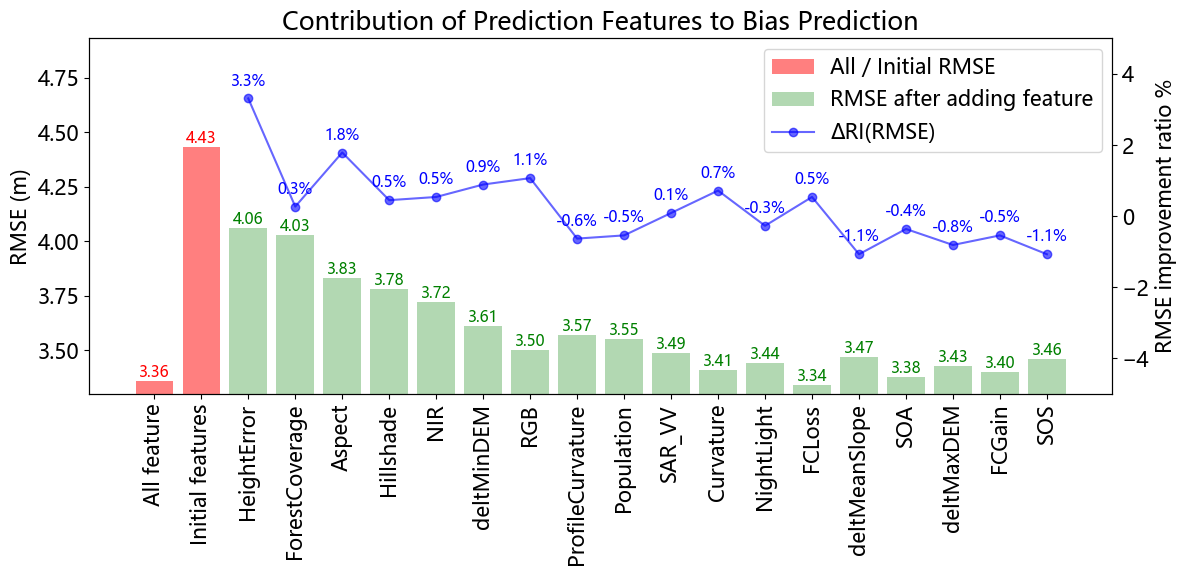

In [ ]:
import matplotlib.pyplot as plt


plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'Microsoft YaHei'



filtered_features=['HeightError','ForestCoverage', 'Aspect', 'Hillshade',  'NIR', 'deltMinDEM', 'RGB', 'ProfileCurvature', 'Population', 'SAR_VV', 
                   'Curvature', 'NightLight',  'FCLoss', 'deltMeanSlope', 'SOA', 'deltMaxDEM',  'FCGain', 'SOS' ]

current_features = ["DEM", "BuildingHeight90", "ForestHeight", "ForestHeight10","ForestHeight30"]


addRMSE_list = [3.36, 4.43] + [ 4.06, 4.03, 3.83, 3.78, 3.72, 3.61, 3.50, 3.57, 3.55, 3.49, 3.41, 3.44, 3.34, 3.47,3.38, 3.43, 3.40, 3.46 ]
Imp_list = [None, None] +  [3.31, 0.27, 1.79, 0.45, 0.54, 0.89, 1.07, -0.63, -0.54, 0.09, 0.72, -0.27, 0.54, -1.07, -0.36, -0.81, -0.54, -1.07]



all_features = ["All feature", "Initial features"] + filtered_features
X = list(range(1, len(all_features) + 1 ))

plt.figure(figsize=(12, 6))  


ax1 = plt.gca()

ax1.bar(X[0], addRMSE_list[0], color='red', alpha=0.5)

ax1.bar(X[1], addRMSE_list[1], color='red', alpha=0.5, label='All / Initial RMSE')

ax1.bar(X[2:], addRMSE_list[2:], color='green', alpha=0.3, label='RMSE after adding feature')
ax1.set_ylabel('RMSE (m)')
ax1.set_ylim(3.3, max(addRMSE_list) + 0.5)


for i, v in zip(X, addRMSE_list):
    if i == 1:
        ax1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom',  fontsize=11, color='red')
    elif i == 2:
        ax1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom',  fontsize=11, color='red')
    else:
        ax1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom',  fontsize=11, color='green')


ax2 = ax1.twinx()

ax2.plot(X[2:], Imp_list[2:], color='blue', marker='o', alpha=0.6, label='ΔRI(RMSE)')
ax2.set_ylabel('RMSE improvement ratio %')
ax2.set_ylim(-5, 5)


for i, v in zip(X[2:], Imp_list[2:]):
 
    ax2.annotate(f'{v:.1f}%', (i, v+0.25), ha='center', va='bottom', color='blue', fontsize=11)
   

ax1.set_xticks(X)
ax1.set_xticklabels(all_features, rotation=90)

plt.title('Contribution of Prediction Features to Bias Prediction')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()
